In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ground_truth.csv to ground_truth.csv
Saving observations.csv to observations.csv


In [ ]:
# 1. Count Minimum Sequence Length from Observations
# Load the data
obs_df = pd.read_csv("observations.csv")
gt_df = pd.read_csv("ground_truth.csv")

# Get sequence lengths per tracklet
seq_lengths = obs_df.groupby("Track_ID").size()
seq_len  = seq_lengths.min()

print("Minimum sequence length (per Track_ID):", seq_len)

Minimum sequence length (per Track_ID): 4


In [ ]:
# Step 4: Build Tracklets
def build_tracklets(obs_df, gt_df, seq_len):
    scaler_az_el = MinMaxScaler()
    scaler_az_el.fit(obs_df[['Azimuth', 'Elevation']])

    all_tracklets, all_targets = [], []
    for track_id in gt_df['Track_ID']:
        track_obs = obs_df[obs_df['Track_ID'] == track_id].sort_values('MJD')
        if len(track_obs) < seq_len:
            continue
        az_el = scaler_az_el.transform(track_obs[['Azimuth', 'Elevation']])
        delta_t = track_obs['MJD'].values - track_obs['MJD'].values[len(track_obs)//2]
        sequence = np.hstack([az_el, delta_t.reshape(-1, 1)])[:seq_len]
        all_tracklets.append(sequence)
        all_targets.append(gt_df[gt_df['Track_ID'] == track_id].iloc[0, 1:].values.astype(np.float32))
    return np.array(all_tracklets), np.array(all_targets), scaler_az_el

tracklets, targets, input_scaler = build_tracklets(obs_df, gt_df, seq_len)

# Step 5: Normalize Targets
target_scaler = StandardScaler()
targets_scaled = target_scaler.fit_transform(targets)

In [ ]:
# Step 6: PyTorch Dataset
class OrbitDataset(Dataset):
    def __init__(self, tracklets, targets):
        self.tracklets = torch.tensor(tracklets, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    def __len__(self): return len(self.tracklets)
    def __getitem__(self, idx): return self.tracklets[idx], self.targets[idx]

dataset = OrbitDataset(tracklets, targets_scaled)

In [ ]:
# Step 7: Train/Test Split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4)


In [ ]:
# Step 8: Define the LSTM Model
class AzElLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=3, hidden_size=128, num_layers=2,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(128 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        mid_idx = x.shape[1] // 2
        return self.fc(lstm_out[:, mid_idx, :])

model = AzElLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [ ]:
# Step 9: Training Loop
losses = []
for epoch in range(100):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d} - Loss: {avg_loss:.6f}")

Epoch   1 - Loss: 0.474496
Epoch   2 - Loss: 0.325879
Epoch   3 - Loss: 0.322120
Epoch   4 - Loss: 0.325136
Epoch   5 - Loss: 0.319965
Epoch   6 - Loss: 0.321127
Epoch   7 - Loss: 0.318285
Epoch   8 - Loss: 0.319657
Epoch   9 - Loss: 0.317221
Epoch  10 - Loss: 0.309542
Epoch  11 - Loss: 0.307660
Epoch  12 - Loss: 0.298642
Epoch  13 - Loss: 0.282515
Epoch  14 - Loss: 0.275583
Epoch  15 - Loss: 0.281136
Epoch  16 - Loss: 0.277914
Epoch  17 - Loss: 0.275663
Epoch  18 - Loss: 0.276069
Epoch  19 - Loss: 0.276067
Epoch  20 - Loss: 0.275278
Epoch  21 - Loss: 0.271878
Epoch  22 - Loss: 0.270472
Epoch  23 - Loss: 0.272205
Epoch  24 - Loss: 0.270101
Epoch  25 - Loss: 0.281189
Epoch  26 - Loss: 0.268732
Epoch  27 - Loss: 0.273613
Epoch  28 - Loss: 0.278003
Epoch  29 - Loss: 0.273081
Epoch  30 - Loss: 0.275523
Epoch  31 - Loss: 0.268376
Epoch  32 - Loss: 0.270560
Epoch  33 - Loss: 0.269618
Epoch  34 - Loss: 0.265898
Epoch  35 - Loss: 0.268984
Epoch  36 - Loss: 0.267552
Epoch  37 - Loss: 0.266536
E

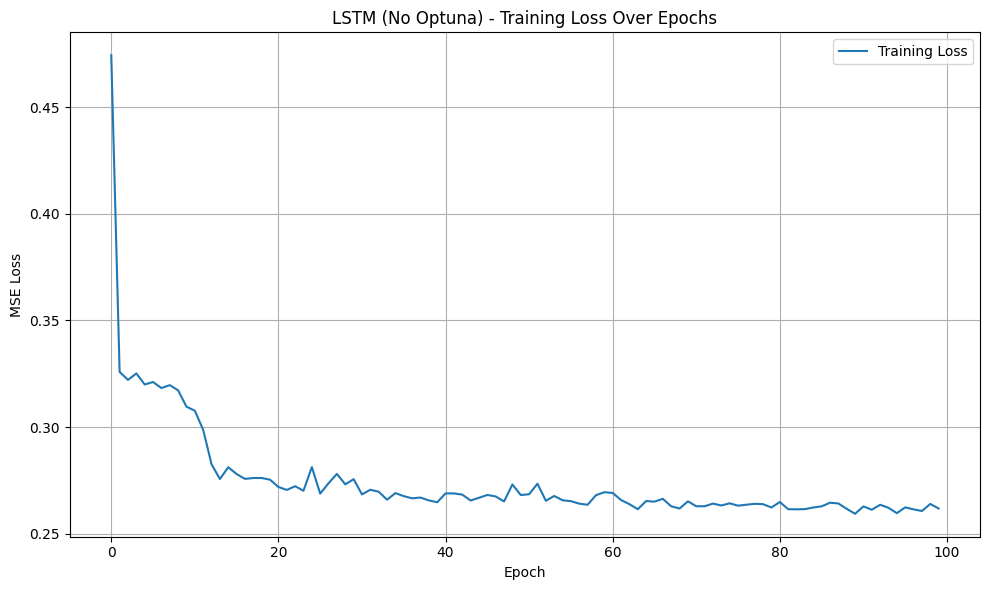

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM (No Optuna) - Training Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Step 11: Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb)
        y_true.append(yb.numpy())
        y_pred.append(pred.numpy())

y_true = target_scaler.inverse_transform(np.vstack(y_true))
y_pred = target_scaler.inverse_transform(np.vstack(y_pred))


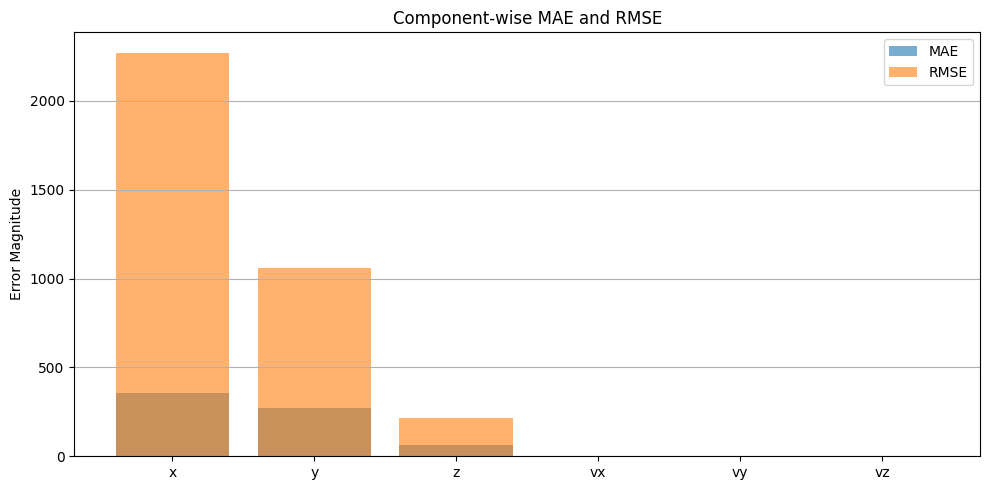

In [ ]:
# Step 14: Bar Plot for MAE & RMSE
mae = np.mean(np.abs(y_true - y_pred), axis=0)
rmse = np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

plt.figure(figsize=(10, 5))
plt.bar(labels, mae, alpha=0.6, label='MAE')
plt.bar(labels, rmse, alpha=0.6, label='RMSE')
plt.title("Component-wise MAE and RMSE")
plt.ylabel("Error Magnitude")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

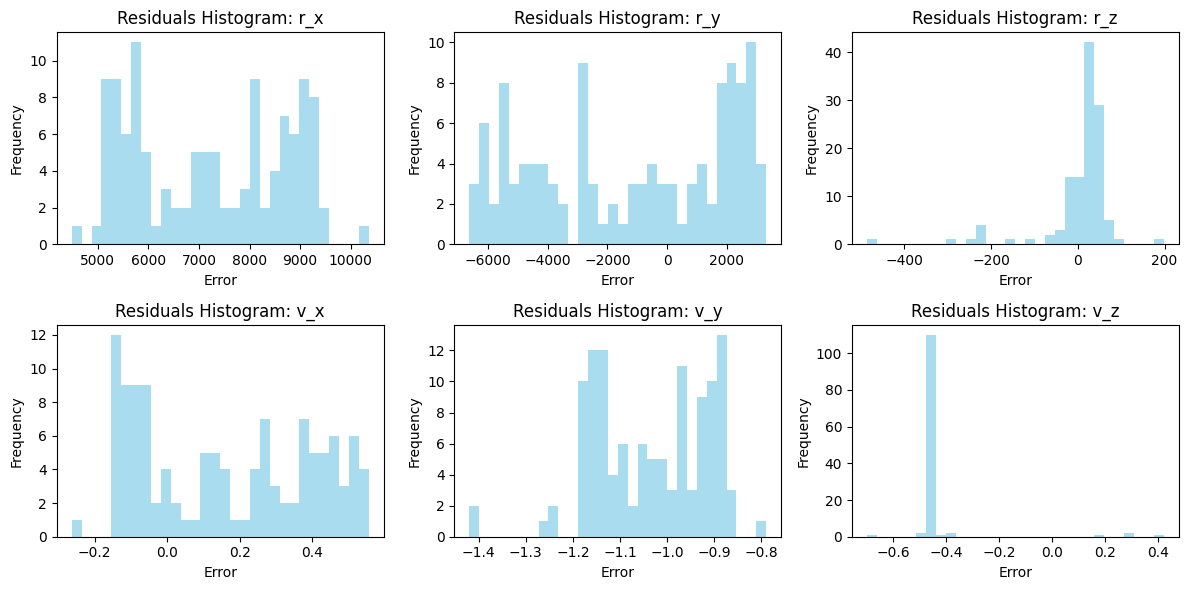

In [ ]:
residuals = truths - preds
labels_full = ['r_x', 'r_y', 'r_z', 'v_x', 'v_y', 'v_z']

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.hist(residuals[:, i], bins=30, alpha=0.7, color='skyblue')
    plt.title(f"Residuals Histogram: {labels_full[i]}")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


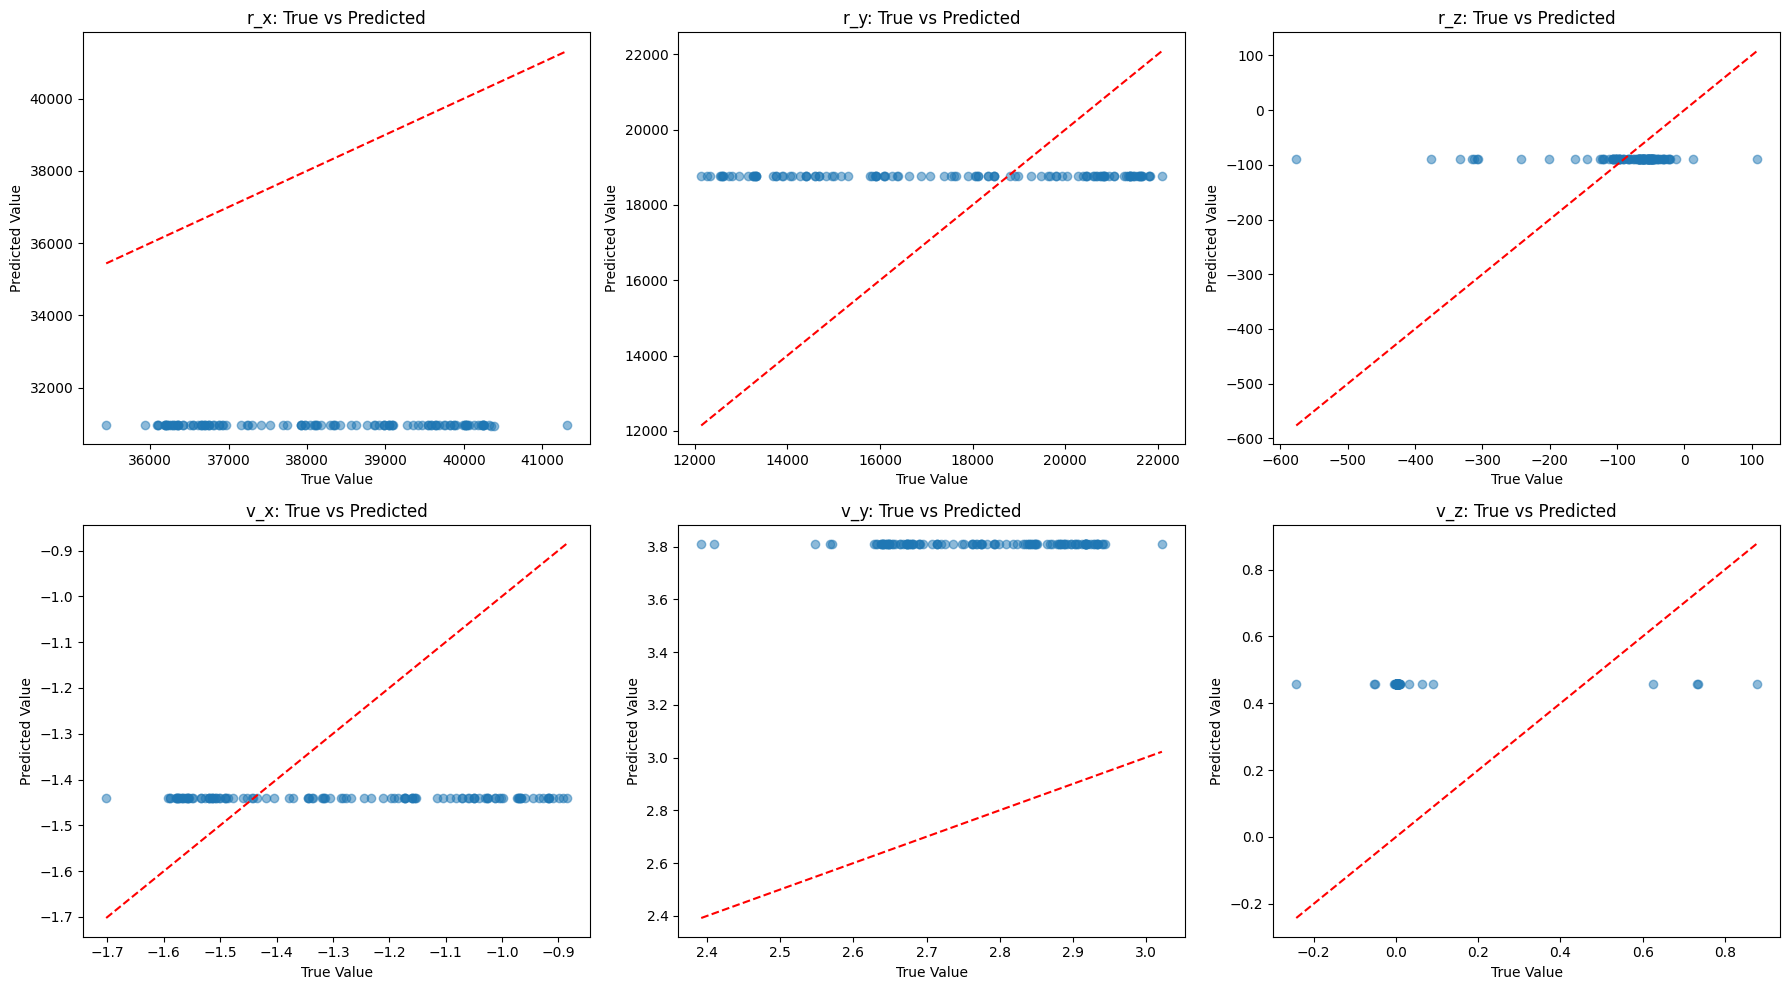

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(6):
    axes[i].scatter(truths[:, i], preds[:, i], alpha=0.5)
    axes[i].plot([min(truths[:, i]), max(truths[:, i])],
                 [min(truths[:, i]), max(truths[:, i])], 'r--')
    axes[i].set_title(f"{labels_full[i]}: True vs Predicted")
    axes[i].set_xlabel("True Value")
    axes[i].set_ylabel("Predicted Value")

plt.tight_layout()
plt.show()


In [ ]:
# Step 15: Print Error Table (MAE and RMSE) and Percentage Errors

# Compute percentage error relative to mean truth value
percent_mae = 100 * mae / np.mean(np.abs(y_true), axis=0)
percent_rmse = 100 * rmse / np.mean(np.abs(y_true), axis=0)

# Print as table
error_df = pd.DataFrame({
    'MAE': mae,
    'RMSE': rmse,
    'MAE (%)': percent_mae,
    'RMSE (%)': percent_rmse
}, index=labels)

print("\n=== MAE and RMSE Table ===")
print(error_df.to_string(float_format="{:8.3f}".format))

# Optional: Detailed individual print
print("\n=== Detailed Error Breakdown ===")
units = ['km', 'km', 'km', 'km/s', 'km/s', 'km/s']
for i, name in enumerate(labels):
    print(f"{name} MAE:  {mae[i]:8.2f} {units[i]:<5} ({percent_mae[i]:6.2f}%)")
    print(f"{name} RMSE: {rmse[i]:8.2f} {units[i]:<5} ({percent_rmse[i]:6.2f}%)")



=== MAE and RMSE Table ===
        MAE     RMSE  MAE (%)  RMSE (%)
x   358.857 2272.086    0.936     5.926
y   274.344 1060.826    1.547     5.980
z    61.812  212.852   59.424   204.631
vx    0.025    0.093    1.977     7.318
vy    0.050    0.277    1.809    10.104
vz    0.071    0.160  155.505   348.776

=== Detailed Error Breakdown ===
x MAE:    358.86 km    (  0.94%)
x RMSE:  2272.09 km    (  5.93%)
y MAE:    274.34 km    (  1.55%)
y RMSE:  1060.83 km    (  5.98%)
z MAE:     61.81 km    ( 59.42%)
z RMSE:   212.85 km    (204.63%)
vx MAE:      0.03 km/s  (  1.98%)
vx RMSE:     0.09 km/s  (  7.32%)
vy MAE:      0.05 km/s  (  1.81%)
vy RMSE:     0.28 km/s  ( 10.10%)
vz MAE:      0.07 km/s  (155.50%)
vz RMSE:     0.16 km/s  (348.78%)
